# IMPORT

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 1. Dataset Exploration

In [31]:
df = pd.read_csv(r"C:\Users\ngarg\Downloads\train1.csv")
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.shape

(42000, 785)

In [33]:
df['label'].nunique()

10

In [34]:
df['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [35]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [37]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


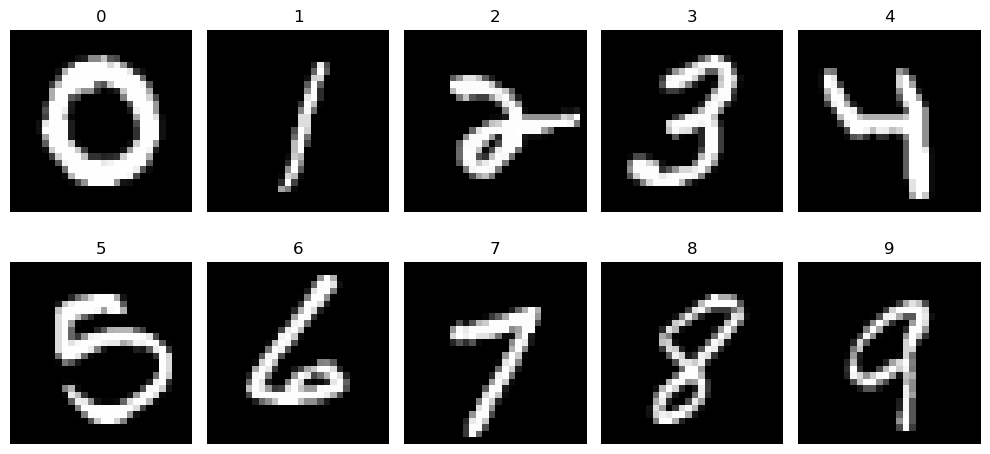

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

indices = [1, 15, 34, 70, 921, 1081, 998, 961, 1026, 41999]

for ax, idx in zip(axes.ravel(), indices):
    sample = df.iloc[idx]
    label = sample['label']
    image = sample.drop('label').values.reshape(28, 28)

    ax.imshow(image, cmap='grey')
    ax.set_title(f"{label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [39]:
x = df.drop(columns = ['label'])
y = df['label']

In [40]:
x = x.astype(np.float32)
x = x / 255.0

In [41]:
x.shape

(42000, 784)

## 3. CNN

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42 ,stratify=y)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [43]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28,1)

In [44]:
X_train_cnn.shape

(29400, 28, 28, 1)

In [45]:
y_train.shape

(29400,)

In [46]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [47]:
print(X_train_cnn.shape)
print(y_train.shape)

print(np.isnan(X_train_cnn).any())
print(np.isnan(y_train).any())

(29400, 28, 28, 1)
(29400,)
False
False


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , Conv2D , MaxPooling2D , Flatten

In [49]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

c:\Users\ngarg\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8358 - loss: 0.5391 - val_accuracy: 0.9607 - val_loss: 0.1281
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9541 - loss: 0.1554 - val_accuracy: 0.9750 - val_loss: 0.0828
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9672 - loss: 0.1086 - val_accuracy: 0.9787 - val_loss: 0.0672
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9735 - loss: 0.0876 - val_accuracy: 0.9827 - val_loss: 0.0587
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9773 - loss: 0.0743 - val_accuracy: 0.9844 - val_loss: 0.0514
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9804 - loss: 0.0623 - val_accuracy: 0.9838 - val_loss: 0.0499
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9825 - loss: 0.0544 - val_accuracy: 0.9840 - val_loss: 0.0503
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9838 - loss: 0.0496 - val_accu

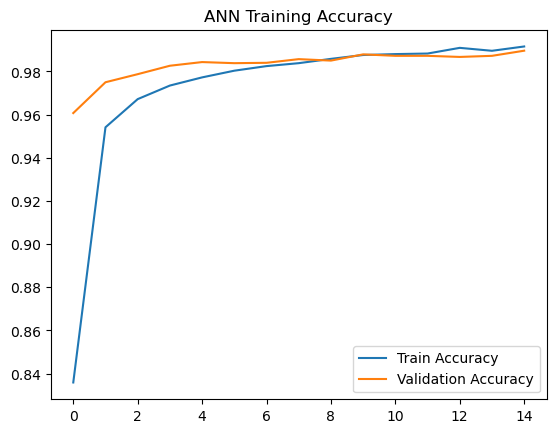

In [52]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Training Accuracy")
plt.legend()
plt.show()

In [53]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("ANN Test Accuracy:", test_acc)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9882 - loss: 0.0442
ANN Test Accuracy: 0.9881746172904968


In [54]:
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [55]:
cm = confusion_matrix(y_test, y_pred)

labels = [0,1,2,3,4,5,6,7,8,9]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"
cm_df


Predicted,0,1,2,3,4,5,6,7,8,9
Actual,,,,,,,,,,
0,1228,1,1,0,0,1,5,0,2,2
1,0,1398,3,0,1,1,0,0,2,0
2,0,1,1241,2,2,0,1,6,0,0
3,2,1,6,1283,0,4,0,3,3,3
4,1,4,1,0,1210,0,1,0,0,5
5,0,0,0,6,0,1121,6,0,5,1
6,0,0,0,0,1,3,1234,0,3,0
7,0,1,9,1,7,0,0,1300,0,2
8,0,2,5,1,1,2,0,0,1202,6


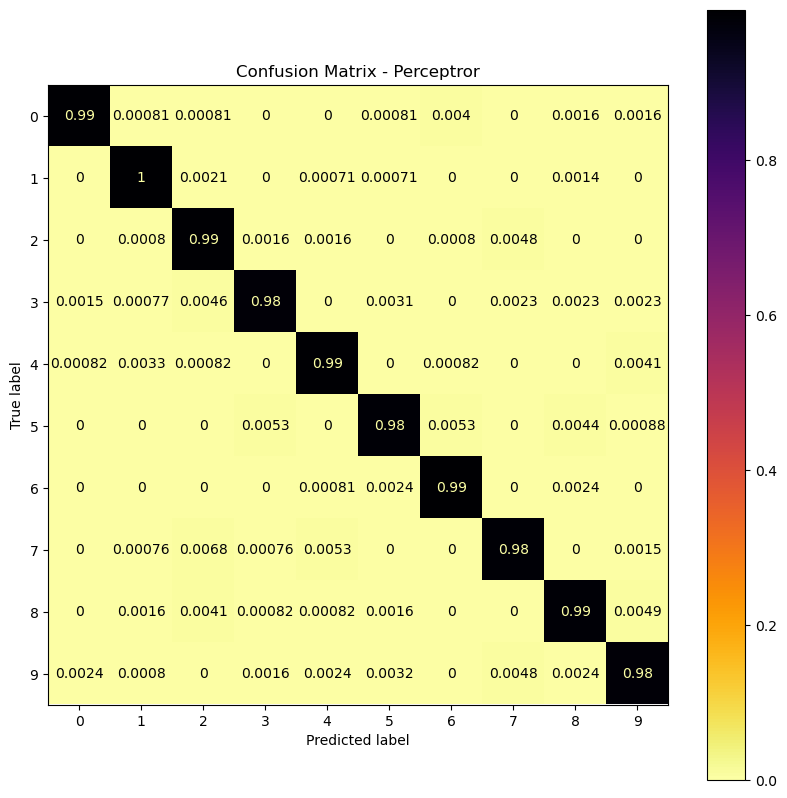

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="inferno_r",
    normalize="true", 
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1240
           1       0.99      1.00      0.99      1405
           2       0.98      0.99      0.99      1253
           3       0.99      0.98      0.99      1305
           4       0.99      0.99      0.99      1222
           5       0.99      0.98      0.99      1139
           6       0.99      0.99      0.99      1241
           7       0.99      0.98      0.99      1320
           8       0.99      0.99      0.99      1219
           9       0.98      0.98      0.98      1256

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



#  Results and Observation (CNN Model)

---

## 1. Model Performance

The Convolutional Neural Network (CNN) model was trained using convolutional layers for feature extraction followed by dense layers for classification.

The final CNN model achieved a test accuracy of approximately **0.986–0.99 (98.6% – 99%)**

The model showed fast convergence and stable learning, with both training and validation accuracy increasing consistently over epochs.

---

## 2. Training Analysis

During training, the CNN model showed:

- Rapid improvement in accuracy from the first few epochs
- Smooth decrease in training and validation loss
- High validation accuracy closely matching training accuracy

This indicates strong generalization and very low overfitting due to proper architecture and dropout regularization.

---

## 3. Classification Report Analysis

The classification report shows excellent performance across all digit classes.

- Most digits (0, 1, 2, 3, 4, 6, 7) achieved precision and recall close to **0.99**
- Slight variations are observed in digits like **2 , 5 and 9**, but errors are minimal
- Overall macro and weighted averages are approximately **0.99**

This confirms that CNN effectively captures spatial and structural features of handwritten digits.

---

## 4. Confusion Matrix Analysis

The confusion matrix shows that:

- Most predictions are correctly aligned along the diagonal
- Very few misclassifications occur between similar digits (e.g., 8 and 9, 4 and 9)
- Error rate is extremely low compared to Perceptron and ANN models

This demonstrates the strength of CNN in image-based classification tasks.

---

## 5. Final Observation

The CNN model significantly outperforms both Perceptron and ANN models.

It is able to learn spatial hierarchies such as edges, curves, and shapes, which improves classification accuracy dramatically.

CNN is therefore the most effective model for MNIST digit recognition.

---

## 6. Code Output Summary

- Test Accuracy: **~0.986 – 0.99**
- Precision / Recall / F1-score: **~0.99**
- Error Rate: Very low
- Best performing model among all three

---

## Conclusion

CNN is the most powerful model for image classification tasks like MNIST due to its ability to automatically extract spatial features and learn hierarchical patterns.

In [58]:
model.save(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\CNN\cnn_model.h5")